# EEG Trigger Press · LightGBM + Engineered Features
## Focused Analysis with Rich Visualizations

Best pipeline from `eeg_pipeline_v2`: **LightGBM on temporal + frequency features**,
LOTO cross-validation, AP-optimised threshold.

**Visualizations**
1. Per-trial probability timeline — model score vs true horizon labels across each full trial
2. Event-related probability — average score trace locked to each press event (ERP-style)
3. Press event zoom gallery — individual 3 s windows around each detected press
4. Per-fold AUC / AP / EvtSens bar chart
5. ROC & Precision-Recall curves
6. Feature importance (mean across LOTO folds)


## 1 · Imports

In [1]:
import warnings

warnings.filterwarnings("ignore")
import os
import sys

import lightgbm as lgb
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy.signal import welch
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

sys.path.insert(0, "..")
from src.postproc import event_detection_metrics
from src.preprocessing import (
    build_windows,
    euclidean_align,
    load_trial,
    make_horizon_labels,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

DARK, CARD, EDGE = "#0a0e17", "#111827", "#1f2937"
TEAL, CORAL, GOLD, WHITE = "#00e5cc", "#ff4f5e", "#ffc947", "#f0f4ff"
LIME, PURPLE = "#a8ff3e", "#c084fc"

print("Imports OK  (LightGBM", lgb.__version__, ")")

Imports OK  (LightGBM 4.6.0 )


## 2 · Config

In [2]:
SUBJECT = 9
TACHE = "spt"
ALL_TRIALS = list(range(10))
TEST_TRIALS = list(range(10))  # trial 0 is calibration — always in train
DATA_PATH = f"../data/subject{SUBJECT}/"

FS, DECIM = 250, 4
FS_EFF = FS // DECIM  # 62 Hz
LP, HP = 0.5, 8.0
HORIZON = int(0.5 * FS_EFF)  # 500 ms look-ahead  (was 97 ms — too few positives)
TARGET = "button"
T_MAX = int(2.0 * FS_EFF)  # upper bound for T search
T_MIN = int(0.2 * FS_EFF)  # lower bound for T search (1 s)

MIN_SPEC = 0.9
SMOOTH_WIN = max(1, int(0.1 * FS_EFF))  # 100 ms
REFRACTORY = int(0.5 * FS_EFF)  # 500 ms post-detection suppression

N_OPTUNA = 25
TRAIN_CAP = 50_000
SEED = 42

print(
    f"FS_EFF={FS_EFF} Hz  T_MAX={T_MAX} samp ({T_MAX/FS_EFF:.1f} s)  "
    f"HORIZON={HORIZON} samp ({HORIZON/FS_EFF*1000:.0f} ms)  "
    f"SMOOTH={SMOOTH_WIN} samp ({SMOOTH_WIN/FS_EFF*1000:.0f} ms)"
)
print(
    f"MIN_SPEC={MIN_SPEC}  REFRACTORY={REFRACTORY} samp ({REFRACTORY/FS_EFF*1000:.0f} ms)  TEST_TRIALS={TEST_TRIALS}"
)
print(
    f"T search: {T_MIN} samp ({T_MIN/FS_EFF*1000:.0f} ms) … {T_MAX} samp ({T_MAX/FS_EFF*1000:.0f} ms)"
)

FS_EFF=62 Hz  T_MAX=124 samp (2.0 s)  HORIZON=31 samp (500 ms)  SMOOTH=6 samp (97 ms)
MIN_SPEC=0.9  REFRACTORY=31 samp (500 ms)  TEST_TRIALS=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
T search: 12 samp (194 ms) … 124 samp (2000 ms)


## 3 · Load & Filter

In [3]:
print("Loading (CAR + trial_zscore + 0.5–8 Hz) …")
raw_data, EEG_COLS = {}, None

for t in ALL_TRIALS:
    df, cols = load_trial(
        SUBJECT,
        TACHE,
        t,
        DATA_PATH,
        eeg_cols=EEG_COLS,
        lp=LP,
        hp=HP,
        decimate=DECIM,
        car=True,
        trial_zscore=True,
    )
    if EEG_COLS is None:
        EEG_COLS = cols
    X_t = df[EEG_COLS].values.astype(np.float32)
    y_t = make_horizon_labels(df[TARGET].values.astype(int), HORIZON)
    y_mom_t = df[TARGET].values.astype(np.int8)
    raw_data[t] = (X_t, y_t, y_mom_t)
    n_pos = int(y_t.sum())
    print(
        f"  trial {t:2d}: {len(df):5,} samp  press={n_pos:5,} ({n_pos/len(df)*100:.1f}%)"
    )

# Validate REFRACTORY against inter-press intervals
# Refractory must be < p5 IPI or it will suppress real press events
_all_ipi = []
for _X_t, _y_t, _y_mom_t in raw_data.values():
    _onsets = np.where(_y_mom_t > 0)[0]
    if len(_onsets) > 1:
        _all_ipi.extend((np.diff(_onsets) / FS_EFF * 1000).tolist())
_ipi = np.array(_all_ipi)
_p5 = float(np.percentile(_ipi, 5))
_ref_ms = REFRACTORY / FS_EFF * 1000
_ok = _ref_ms < _p5
print(
    f"\nIPI  min={_ipi.min():.0f}ms  p5={_p5:.0f}ms  mean={_ipi.mean():.0f}ms"
    f"  →  REFRACTORY={_ref_ms:.0f}ms  "
    + (
        "OK"
        if _ok
        else f"WARNING: REFRACTORY > p5 IPI ({_p5:.0f}ms) — may suppress real events"
    )
)
del _all_ipi, _ipi, _p5, _ref_ms, _ok

N_CH = len(EEG_COLS)
print(f"{N_CH} channels.")

Loading (CAR + trial_zscore + 0.5–8 Hz) …
  trial  0: 5,085 samp  press=  527 (10.4%)
  trial  1: 4,147 samp  press=  589 (14.2%)
  trial  2: 3,891 samp  press=  713 (18.3%)
  trial  3: 4,128 samp  press=  744 (18.0%)
  trial  4: 3,946 samp  press=  892 (22.6%)
  trial  5: 4,362 samp  press=  930 (21.3%)
  trial  6: 4,543 samp  press=  793 (17.5%)
  trial  7: 4,194 samp  press=  866 (20.6%)
  trial  8: 3,750 samp  press=  992 (26.5%)
  trial  9: 4,298 samp  press=1,023 (23.8%)

IPI  min=32ms  p5=1523ms  mean=2281ms  →  REFRACTORY=500ms  OK
16 channels.


## 4 · Feature Engineering

Features computed on **unnormalized** (trial-z-scored only) windows to preserve
MRCP amplitude information. Both functions are vectorized using numpy / scipy.

| Family | Features per channel | Total |
|---|---|---|
| Temporal | mean, std, slope, min_val, argmin_pos, RMS | C × 6 |
| Frequency | delta power (0.5–4 Hz), theta power (4–8 Hz), spectral entropy | C × 3 |


In [4]:
def temporal_features(X3d: np.ndarray) -> np.ndarray:
    """(N, T, C) -> (N, C*6)  fully vectorised."""
    N, T, C = X3d.shape
    X64 = X3d.astype(np.float64)
    t_c = np.arange(T, dtype=np.float64) - (T - 1) / 2.0
    t_var = (t_c**2).sum() + 1e-12

    mean_ = X64.mean(axis=1)
    std_ = X64.std(axis=1)
    slope_ = (X64 * t_c[None, :, None]).sum(axis=1) / t_var
    min_ = X64.min(axis=1)
    argm_ = X64.argmin(axis=1) / T
    rms_ = np.sqrt((X64**2).mean(axis=1))

    return (
        np.stack([mean_, std_, slope_, min_, argm_, rms_], axis=2)
        .reshape(N, C * 6)
        .astype(np.float32)
    )


def freq_features(X3d: np.ndarray, fs: float, batch: int = 2000) -> np.ndarray:
    """(N, T, C) -> (N, C*3)  batched Welch PSD."""
    N, T, C = X3d.shape
    nperseg = min(T, 64)
    out = np.zeros((N, C * 3), dtype=np.float32)

    for s in range(0, N, batch):
        x_b = X3d[s : s + batch].transpose(0, 2, 1)
        f, p = welch(x_b, fs=fs, nperseg=nperseg, axis=-1)
        df = f[1] - f[0]
        m_d = (f >= 0.5) & (f <= 4.0)
        m_t = (f >= 4.0) & (f <= 8.0)
        m_a = f > 0
        dp = p[:, :, m_d].sum(axis=-1) * df
        tp = p[:, :, m_t].sum(axis=-1) * df
        pn = p[:, :, m_a] / (p[:, :, m_a].sum(-1, keepdims=True) + 1e-12)
        se = -(pn * np.log(pn + 1e-12)).sum(axis=-1)
        out[s : s + batch, 0::3] = dp
        out[s : s + batch, 1::3] = tp
        out[s : s + batch, 2::3] = se
    return out


def hjorth_features(X3d: np.ndarray) -> np.ndarray:
    """(N, T, C) -> (N, C*3)  vectorised Hjorth parameters (activity, mobility, complexity)."""
    d1 = np.diff(X3d, axis=1)  # (N, T-1, C)
    d2 = np.diff(d1, axis=1)  # (N, T-2, C)
    v0 = X3d.var(axis=1) + 1e-12  # (N, C)
    v1 = d1.var(axis=1) + 1e-12
    v2 = d2.var(axis=1) + 1e-12
    mob = np.sqrt(v1 / v0)
    cmp = np.sqrt(v2 / v1) / (mob + 1e-12)
    return np.stack([v0, mob, cmp], axis=2).reshape(len(X3d), -1).astype(np.float32)


def features_for_T(T: int, X_3d: np.ndarray = None) -> np.ndarray:
    """Compute temporal + frequency + Hjorth features for window length T.

    X_3d: explicit (N, *, C) array (e.g. after Euclidean Alignment); if None,
          slices from the global X_max.
    Returns (N, C*12).
    """
    src = X_3d if X_3d is not None else X_max
    X_t = src[:, -T:, :]
    return np.concatenate(
        [temporal_features(X_t), freq_features(X_t, FS_EFF), hjorth_features(X_t)],
        axis=1,
    ).astype(np.float32)


# Feature names for importance plot
FEAT_NAMES = (
    [
        f"ch{c+1}_{f}"
        for c in range(N_CH)
        for f in ["mean", "std", "slope", "min", "argmin", "rms"]
    ]
    + [f"ch{c+1}_{f}" for c in range(N_CH) for f in ["delta", "theta", "entropy"]]
    + [
        f"ch{c+1}_{f}"
        for c in range(N_CH)
        for f in ["activity", "mobility", "complexity"]
    ]
)

print(f"Feature names defined: {len(FEAT_NAMES)} features")
print(f"  Temporal: {N_CH*6}  Frequency: {N_CH*3}  Hjorth: {N_CH*3}  Total: {N_CH*12}")

Feature names defined: 192 features
  Temporal: 96  Frequency: 48  Hjorth: 48  Total: 192


## 5 · Pre-compute Windows & Feature Matrix

In [5]:
print(
    f"Building windows at T_MAX={T_MAX} ({T_MAX/FS_EFF:.1f} s, upper bound for T search) …"
)
_X, _y, _ymom, _tid = [], [], [], []

for t in ALL_TRIALS:
    X_t, y_t, y_mom_t = raw_data[t]
    Xw, yw = build_windows(X_t, y_t, T_MAX, per_window_norm=False)
    y_mom_w = y_mom_t[T_MAX:][: len(yw)]
    n = min(len(yw), len(y_mom_w))
    _X.append(Xw[:n].reshape(-1, T_MAX, N_CH))
    _y.append(yw[:n])
    _ymom.append(y_mom_w[:n])
    _tid.append(np.full(n, t, dtype=np.int32))

X_max = np.concatenate(_X)  # (M, T_MAX, C) — sliced per Optuna trial
y_all = np.concatenate(_y)
y_mom = np.concatenate(_ymom)
tid_all = np.concatenate(_tid)
del _X, _y, _ymom, _tid

n_pos = int(y_all.sum())
print(f"  {len(y_all):,} windows  {n_pos:,} pos ({n_pos/len(y_all)*100:.1f}%)")
print(f"  X_max shape: {X_max.shape}  (features computed per T inside Optuna)")

Building windows at T_MAX=124 (2.0 s, upper bound for T search) …
  41,104 windows  8,069 pos (19.6%)
  X_max shape: (41104, 124, 16)  (features computed per T inside Optuna)


## 6 · Utilities & LOTO Evaluator

In [6]:
def subsample(X, y, n, seed):
    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(len(y), min(n, len(y)), replace=False))
    return X[idx], y[idx]


def smooth(scores, window=SMOOTH_WIN):
    if window <= 1:
        return scores.copy()
    return (
        pd.Series(scores)
        .rolling(window, min_periods=1)
        .mean()
        .values.astype(np.float32)
    )


def thresh_at_spec(fpr, tpr, thresholds, min_spec=MIN_SPEC):
    valid = (1 - fpr) >= min_spec
    if valid.any():
        return float(thresholds[np.argmax(tpr[valid])])
    return float(thresholds[np.argmax(tpr - fpr)])


def loto_eval(model_fn, X_3d, T_cur, y, tid, y_mom_arr, on_fit=None):
    """
    LOTO CV with per-fold Euclidean Alignment.

    X_3d  : (M, T_MAX, C) raw window array (global X_max)
    T_cur : window length to use (e.g. T_OPT from Optuna)
    Threshold selected on the training fold each time (no leakage).
    on_fit: optional callback(model) called after each fold fit.
    """
    scores = np.zeros(len(y), dtype=np.float32)
    fold_results = []

    for test_trial in TEST_TRIALS:
        te = tid == test_trial
        tr = ~te

        # Per-fold Euclidean Alignment: fit whitening on training windows only
        X_tr_3d = X_3d[tr, -T_cur:, :]  # (N_tr, T_cur, C)
        X_te_3d = X_3d[te, -T_cur:, :]  # (N_te, T_cur, C)
        X_tr_aligned, W = euclidean_align(X_tr_3d)
        X_te_aligned = (X_te_3d @ W.T).astype(np.float32)

        X_feat_tr = features_for_T(T_cur, X_tr_aligned)
        X_feat_te = features_for_T(T_cur, X_te_aligned)
        y_tr = y[tr]
        y_te = y[te]

        model = model_fn(X_feat_tr, y_tr)
        if on_fit is not None:
            on_fit(model)

        sc_tr = model.predict_proba(X_feat_tr)[:, 1]
        sc_te = model.predict_proba(X_feat_te)[:, 1]

        fpr_tr, tpr_tr, thr_tr = roc_curve(y_tr, sc_tr)
        thresh = thresh_at_spec(fpr_tr, tpr_tr, thr_tr)

        scores[te] = sc_te.astype(np.float32)
        auc = roc_auc_score(y_te, sc_te)
        ap = average_precision_score(y_te, sc_te)
        fold_results.append(dict(trial=test_trial, auc=auc, ap=ap, thresh=thresh))
        print(
            f"  fold {test_trial:2d}  AUC={auc:.4f}  AP={ap:.4f}  thresh={thresh:.3f}"
        )

    # Smooth per trial
    scores_s = np.zeros_like(scores)
    for t in TEST_TRIALS:
        m = tid == t
        scores_s[m] = smooth(scores[m])

    thresh_final = float(np.mean([r["thresh"] for r in fold_results]))
    preds = (scores_s >= thresh_final).astype(int)

    auc_mean = float(np.mean([r["auc"] for r in fold_results]))
    ap_mean = float(np.mean([r["ap"] for r in fold_results]))
    test_mask = np.isin(tid, TEST_TRIALS)
    evt = event_detection_metrics(
        scores_s[test_mask],
        y_mom_arr[test_mask],
        threshold=thresh_final,
        horizon=HORIZON,
        fs_eff=FS_EFF,
        refractory=REFRACTORY,
    )

    print(f"\nLOTO AUC : {auc_mean:.4f}  AP : {ap_mean:.4f}")
    print(f"Threshold: {thresh_final:.4f}  (mean of training-fold thresholds)")
    print(
        f"EvtSens  : {evt['event_sensitivity']:.3f}   "
        f"FA/min   : {evt['fa_per_minute']:.1f}   "
        f"Latency  : {evt.get('mean_latency_ms', 0):.1f} ms"
        f"   (refractory={REFRACTORY/FS_EFF*1000:.0f} ms)"
    )

    return dict(
        scores=scores_s,
        scores_raw=scores,
        auc=auc_mean,
        ap=ap_mean,
        thresh=thresh_final,
        preds=preds,
        evt=evt,
        fold_results=fold_results,
    )


print("Utilities ready.")

Utilities ready.


## 7 · Optuna Hyperparameter Search (AUC objective, T_MAX optimised)


In [7]:
def lgb_objective(trial):
    T = trial.suggest_int("T", T_MIN, T_MAX)
    X_f = features_for_T(T)

    params = dict(
        n_estimators=trial.suggest_int("n_est", 100, 600),
        learning_rate=trial.suggest_float("lr", 0.01, 0.3, log=True),
        max_depth=trial.suggest_int("max_d", 3, 9),
        num_leaves=trial.suggest_int("n_leaves", 15, 127),
        min_child_samples=trial.suggest_int("min_ch", 10, 120),
        subsample=trial.suggest_float("sub", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("col", 0.5, 1.0),
        reg_lambda=trial.suggest_float("lam", 1e-3, 10.0, log=True),
    )
    fold_aucs = []
    for fold, t_fold in enumerate(TEST_TRIALS[::2]):
        te = tid_all == t_fold
        X_tr, y_tr = subsample(
            X_f[~te], y_all[~te], TRAIN_CAP, seed=trial.number + fold
        )
        model = lgb.LGBMClassifier(
            **params, class_weight="balanced", random_state=SEED, verbose=-1, n_jobs=1
        )
        model.fit(X_tr, y_tr)
        sc = model.predict_proba(X_f[te])[:, 1]
        fold_aucs.append(roc_auc_score(y_all[te], sc))
        trial.report(float(np.mean(fold_aucs)), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(fold_aucs))


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=0),
)
study.optimize(lgb_objective, n_trials=N_OPTUNA, show_progress_bar=True)

BEST = study.best_params
T_OPT = BEST["T"]
print(
    f"\nBest trial #{study.best_trial.number}  AUC={study.best_value:.4f}  "
    f"T={T_OPT} ({T_OPT/FS_EFF*1000:.0f} ms)"
)
for k, v in BEST.items():
    print(f"  {k}: {v}")

print("\nComputing features with optimal T …")
X_lgb = features_for_T(T_OPT)
print(f"  X_lgb shape: {X_lgb.shape}")

Best trial: 12. Best value: 0.635398: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [09:10<00:00, 22.02s/it]


Best trial #12  AUC=0.6354  T=12 (194 ms)
  T: 12
  n_est: 423
  lr: 0.026588373306819242
  max_d: 9
  n_leaves: 127
  min_ch: 89
  sub: 0.6114239841499921
  col: 0.5167929424672362
  lam: 9.292922421688722

Computing features with optimal T …
  X_lgb shape: (41104, 192)


## 8 · Full LOTO Evaluation

In [8]:
fold_importances = []


def lgb_fn(X_tr, y_tr):
    X_sub, y_sub = subsample(X_tr, y_tr, TRAIN_CAP, seed=SEED)
    model = lgb.LGBMClassifier(
        n_estimators=BEST["n_est"],
        learning_rate=BEST["lr"],
        max_depth=BEST["max_d"],
        num_leaves=BEST["n_leaves"],
        min_child_samples=BEST["min_ch"],
        subsample=BEST["sub"],
        colsample_bytree=BEST["col"],
        reg_lambda=BEST["lam"],
        class_weight="balanced",
        random_state=SEED,
        verbose=-1,
        n_jobs=-1,
    )
    model.fit(X_sub, y_sub)
    return model


print("Running full LOTO (with per-fold Euclidean Alignment) …")
res = loto_eval(
    lgb_fn,
    X_max,
    T_OPT,
    y_all,
    tid_all,
    y_mom,
    on_fit=lambda m: fold_importances.append(m.feature_importances_.copy()),
)

# Unpack for convenience
scores_s = res["scores"]
thresh = res["thresh"]
preds = res["preds"]
fold_results = res["fold_results"]
evt = res["evt"]

# Mean feature importance across folds
mean_imp = np.mean(fold_importances, axis=0)  # (n_features,)
std_imp = np.std(fold_importances, axis=0)

Running full LOTO (with per-fold Euclidean Alignment) …
  fold  0  AUC=0.6792  AP=0.1662  thresh=0.469
  fold  1  AUC=0.7151  AP=0.2427  thresh=0.547
  fold  2  AUC=0.7099  AP=0.3715  thresh=0.536
  fold  3  AUC=0.5934  AP=0.2503  thresh=0.564
  fold  4  AUC=0.4928  AP=0.2427  thresh=0.533
  fold  5  AUC=0.6039  AP=0.3072  thresh=0.592
  fold  6  AUC=0.6582  AP=0.2820  thresh=0.524
  fold  7  AUC=0.6411  AP=0.3032  thresh=0.549
  fold  8  AUC=0.5930  AP=0.3642  thresh=0.604
  fold  9  AUC=0.6610  AP=0.3866  thresh=0.567

LOTO AUC : 0.6348  AP : 0.2916
Threshold: 0.5485  (mean of training-fold thresholds)
EvtSens  : 0.319   FA/min   : 12.7   Latency  : 300.5 ms   (refractory=500 ms)


In [9]:
import pickle

# ── Save demo artifacts for eeg_lgb_live_demo.ipynb ──────────────────────────
DEMO_TRIAL = TEST_TRIALS[-1]   # hold-out trial used in the animation

te_d = tid_all == DEMO_TRIAL
tr_d = ~te_d
X_tr_3d_d        = X_max[tr_d, -T_OPT:, :]
X_tr_aligned_d, W_demo = euclidean_align(X_tr_3d_d)
X_feat_d         = features_for_T(T_OPT, X_tr_aligned_d)
model_demo       = lgb_fn(X_feat_d, y_all[tr_d])

os.makedirs("models", exist_ok=True)
save_path = "models/lgb_demo.pkl"
with open(save_path, "wb") as f:
    pickle.dump(dict(
        model=model_demo, W=W_demo, T_OPT=T_OPT,
        FS=FS, DECIM=DECIM, FS_EFF=FS_EFF,
        LP=LP, HP=HP, HORIZON=HORIZON, SMOOTH_WIN=SMOOTH_WIN,
        thresh=thresh, EEG_COLS=EEG_COLS,
        DEMO_TRIAL=DEMO_TRIAL, SUBJECT=SUBJECT,
        TACHE=TACHE, DATA_PATH=DATA_PATH,
    ), f)
print(f"Saved \u2192 {save_path}  (model trained on all trials except {DEMO_TRIAL})")

Saved → models/lgb_demo.pkl  (model trained on all trials except 9)


## 9 · Trial Probability Timelines

Each panel shows one full LOTO trial (held-out, never seen during training):
- **Gold background** — true horizon label = 1 (press expected within 1 s)
- **Teal curve** — smoothed LightGBM probability
- **Coral dashed** — threshold (selected on training folds)
- **White verticals** — actual button press events

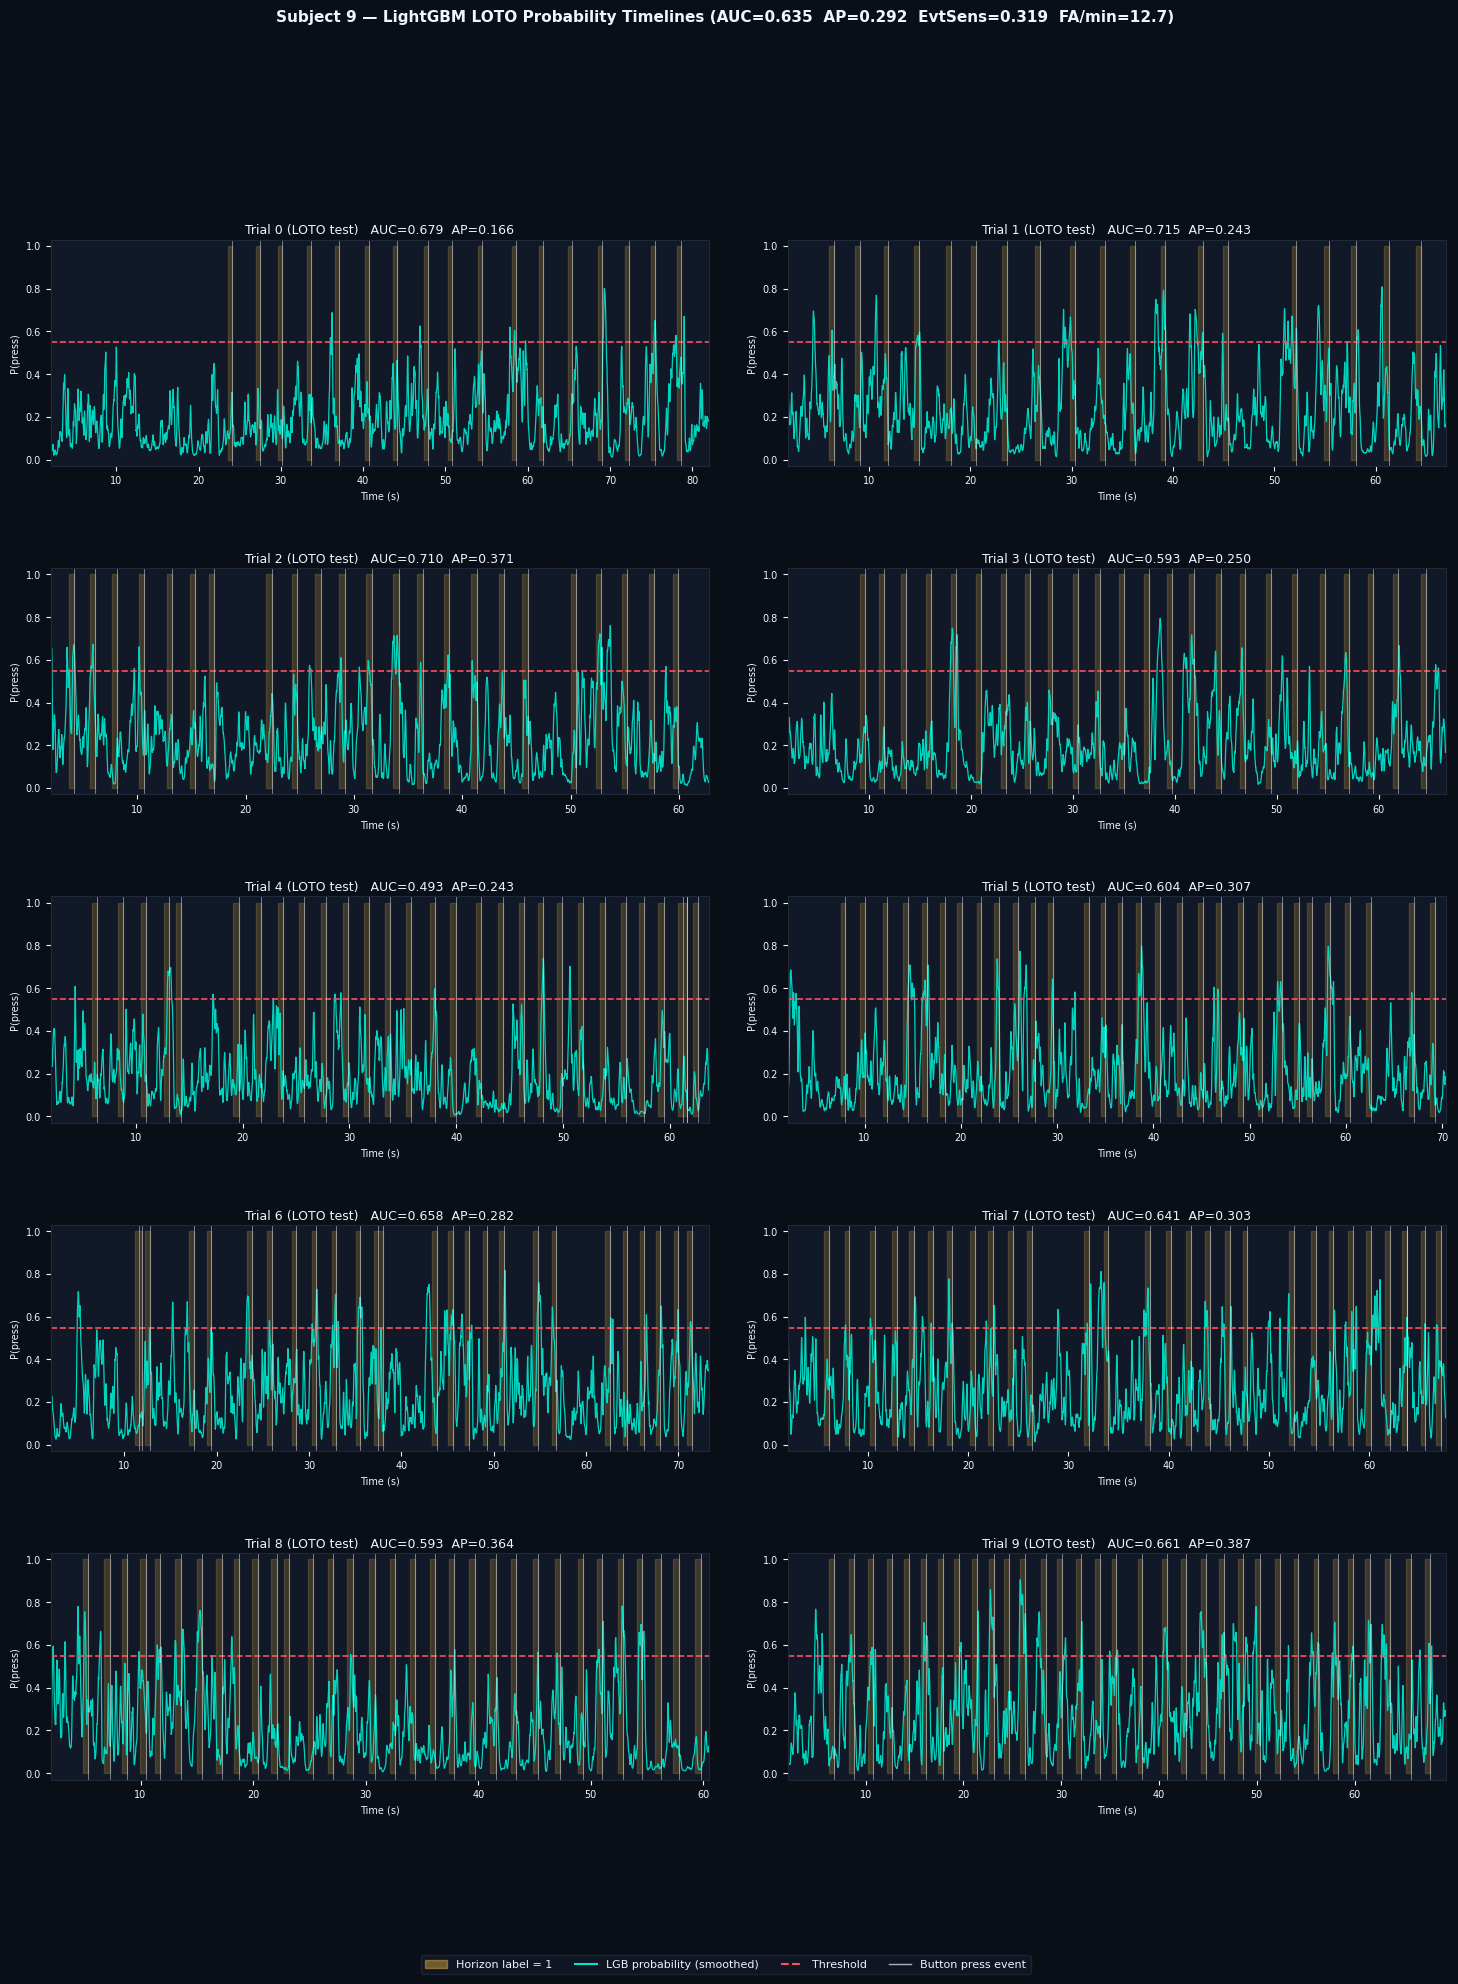

Saved → report/lgb_timelines.png


In [10]:
%matplotlib inline
os.makedirs("report", exist_ok=True)

fold_by_trial = {r["trial"]: r for r in fold_results}

fig, axes = plt.subplots(
    5, 2, figsize=(18, 20), facecolor=DARK, gridspec_kw=dict(hspace=0.45, wspace=0.12)
)

for idx, t in enumerate(ALL_TRIALS):
    ax = axes[idx // 2, idx % 2]
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    ax.tick_params(colors=WHITE, labelsize=7)

    m = tid_all == t
    sc = scores_s[m]
    yl = y_all[m].astype(bool)
    n = m.sum()

    t_sec = (T_MAX + np.arange(n)) / FS_EFF

    ax.fill_between(
        t_sec, 0, 1, where=yl, color=GOLD, alpha=0.18, step="post", label="Label=1"
    )
    ax.plot(t_sec, sc, color=TEAL, lw=0.9, label="P(press)", alpha=0.92)
    ax.axhline(thresh, color=CORAL, lw=1.2, ls="--", label=f"Threshold {thresh:.3f}")

    _, _, y_mom_t = raw_data[t]
    press_samps = np.where(y_mom_t > 0)[0]
    for ps in press_samps:
        ps_time = ps / FS_EFF
        if t_sec[0] <= ps_time <= t_sec[-1]:
            ax.axvline(ps_time, color=WHITE, lw=0.6, alpha=0.55)

    if t in fold_by_trial:
        fold_auc = fold_by_trial[t]["auc"]
        fold_ap = fold_by_trial[t]["ap"]
        title_label = f"Trial {t} (LOTO test)   AUC={fold_auc:.3f}  AP={fold_ap:.3f}"
    else:
        title_label = f"Trial {t} (calibration — train only)"

    ax.set_title(title_label, color=WHITE, fontsize=9, pad=4)
    ax.set_xlim(t_sec[0], t_sec[-1])
    ax.set_ylim(-0.03, 1.03)
    ax.set_xlabel("Time (s)", color=WHITE, fontsize=7)
    ax.set_ylabel("P(press)", color=WHITE, fontsize=7)

handles = [
    mpatches.Patch(color=GOLD, alpha=0.4, label="Horizon label = 1"),
    plt.Line2D([0], [0], color=TEAL, lw=1.5, label="LGB probability (smoothed)"),
    plt.Line2D([0], [0], color=CORAL, lw=1.5, ls="--", label="Threshold"),
    plt.Line2D([0], [0], color=WHITE, lw=1.0, alpha=0.7, label="Button press event"),
]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    facecolor=CARD,
    labelcolor=WHITE,
    edgecolor=EDGE,
    fontsize=8,
    bbox_to_anchor=(0.5, 0.01),
)

fig.suptitle(
    f"Subject {SUBJECT} — LightGBM LOTO Probability Timelines "
    f'(AUC={res["auc"]:.3f}  AP={res["ap"]:.3f}  '
    f'EvtSens={evt["event_sensitivity"]:.3f}  '
    f'FA/min={evt["fa_per_minute"]:.1f})',
    color=WHITE,
    fontsize=11,
    y=0.995,
    fontweight="bold",
)

plt.savefig("report/lgb_timelines.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → report/lgb_timelines.png")

## 10 · Event-Related Probability (ERP-Style)

Average LightGBM probability locked to press events — the EEG analogue of an Event-Related Potential.
If the model captures the Bereitschaftspotential, the curve should **ramp upward ~1 s before the press**.
Detected and missed events are plotted separately to show what the model actually learned.

Events: 84 detected  176 missed  (total=260)


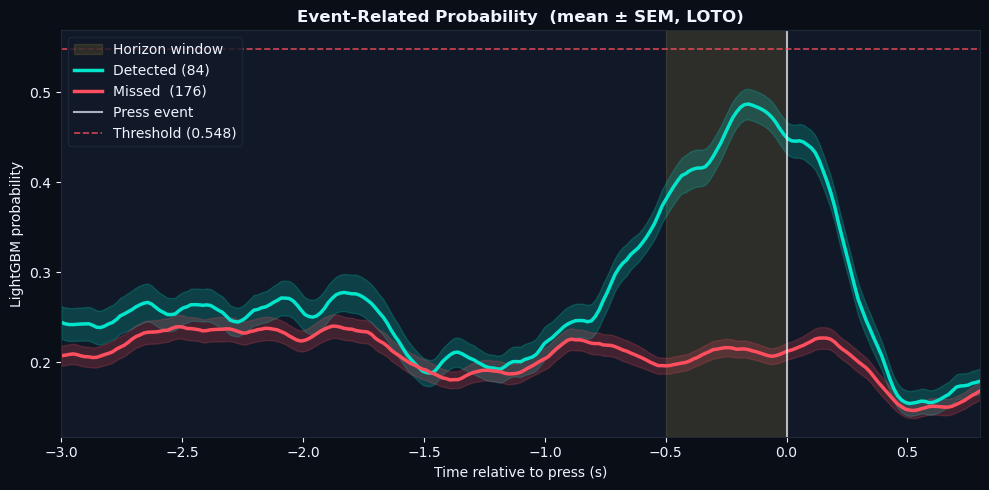

Saved → report/lgb_erp.png


In [11]:
%matplotlib inline

PRE_S, POST_S = 3.0, 0.8  # seconds before / after press
PRE = int(PRE_S * FS_EFF)
POST = int(POST_S * FS_EFF)
t_rel = np.linspace(-PRE_S, POST_S, PRE + POST)  # relative time axis

# Precompute trial start offset in the global scores array
trial_offset = {}
off = 0
for t in ALL_TRIALS:
    trial_offset[t] = off
    off += int((tid_all == t).sum())

erp_det, erp_mis = [], []  # detected / missed press events

for t in ALL_TRIALS:
    _, _, y_mom_t = raw_data[t]
    press_samps = np.where(y_mom_t > 0)[0]
    n_win_t = int((tid_all == t).sum())

    for ps in press_samps:
        win_k = ps - T_MAX  # index within this trial's windows
        if win_k < PRE or win_k + POST > n_win_t:
            continue
        gl_k = trial_offset[t] + win_k  # global index into scores_s
        epoch = scores_s[gl_k - PRE : gl_k + POST]
        if len(epoch) != PRE + POST:
            continue
        # Was this event detected? Check max score in horizon window
        win_start = max(0, gl_k - HORIZON)
        if scores_s[win_start : gl_k + 1].max() >= thresh:
            erp_det.append(epoch)
        else:
            erp_mis.append(epoch)

print(
    f"Events: {len(erp_det)} detected  {len(erp_mis)} missed  "
    f"(total={len(erp_det)+len(erp_mis)})"
)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE)

# HORIZON shading (-1 s to 0)
ax.axvspan(-HORIZON / FS_EFF, 0, color=GOLD, alpha=0.12, label="Horizon window")

for epochs, color, label in [
    (erp_det, TEAL, f"Detected ({len(erp_det)})"),
    (erp_mis, CORAL, f"Missed  ({len(erp_mis)})"),
]:
    if not epochs:
        continue
    arr = np.array(epochs)  # (N_events, T)
    mean = arr.mean(axis=0)
    sem = arr.std(axis=0) / np.sqrt(len(arr))
    ax.plot(t_rel, mean, color=color, lw=2.5, label=label)
    ax.fill_between(t_rel, mean - sem, mean + sem, color=color, alpha=0.2)

ax.axvline(0, color=WHITE, lw=1.5, ls="-", alpha=0.7, label="Press event")
ax.axhline(
    thresh, color=CORAL, lw=1.2, ls="--", alpha=0.8, label=f"Threshold ({thresh:.3f})"
)

ax.set_xlabel("Time relative to press (s)", color=WHITE)
ax.set_ylabel("LightGBM probability", color=WHITE)
ax.set_title(
    "Event-Related Probability  (mean ± SEM, LOTO)", color=WHITE, fontweight="bold"
)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)
ax.set_xlim(-PRE_S, POST_S)

plt.tight_layout()
plt.savefig("report/lgb_erp.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → report/lgb_erp.png")

## 11 · Press Event Zoom Gallery

Each panel shows the 3.5 s window leading up to one individual press event.
**Green border** = detected (score ≥ threshold before press), **Red border** = missed.
The MRCP ramp should be visible as a rising probability in the last ~1 s before press.

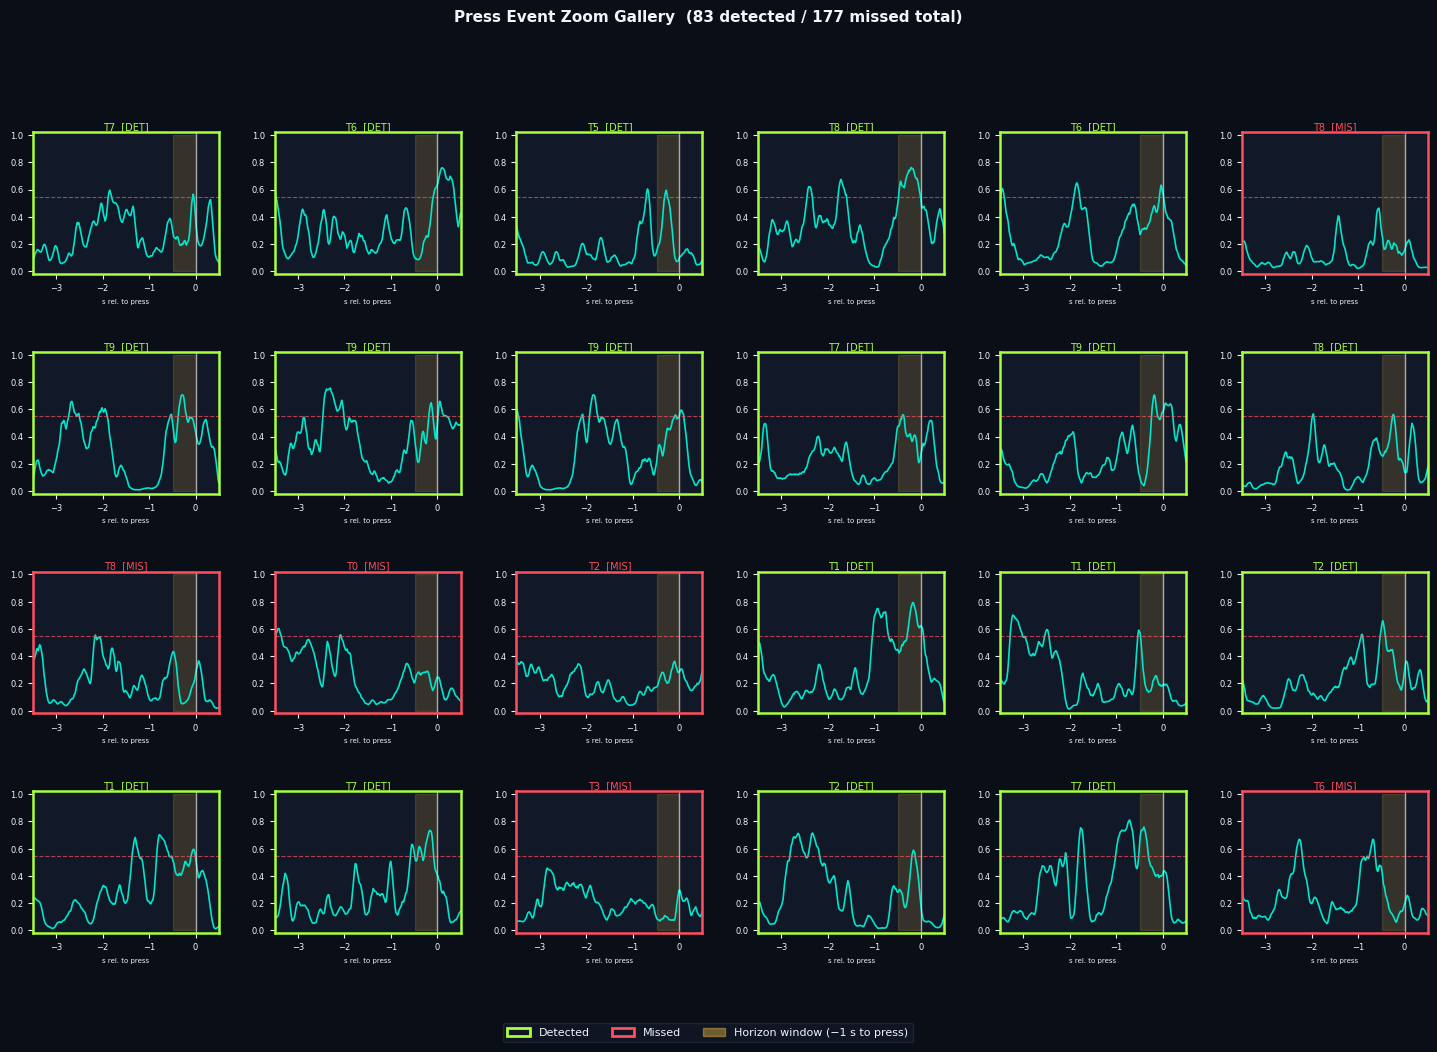

Saved → report/lgb_event_zoom.png  (24 events shown)


In [12]:
%matplotlib inline

ZOOM_PRE_S = 3.5
ZOOM_POST_S = 0.5
ZOOM_PRE = int(ZOOM_PRE_S * FS_EFF)
ZOOM_POST = int(ZOOM_POST_S * FS_EFF)
t_zoom_rel = np.linspace(-ZOOM_PRE_S, ZOOM_POST_S, ZOOM_PRE + ZOOM_POST)

# Collect individual press event windows
events = []  # list of (epoch, detected, trial)
for t in ALL_TRIALS:
    _, _, y_mom_t = raw_data[t]
    press_samps = np.where(y_mom_t > 0)[0]
    n_win_t = int((tid_all == t).sum())
    for ps in press_samps:
        win_k = ps - T_MAX
        if win_k < ZOOM_PRE or win_k + ZOOM_POST > n_win_t:
            continue
        gl_k = trial_offset[t] + win_k
        epoch = scores_s[gl_k - ZOOM_PRE : gl_k + ZOOM_POST]
        if len(epoch) != ZOOM_PRE + ZOOM_POST:
            continue
        win_start = max(0, gl_k - HORIZON)
        detected = bool(scores_s[win_start : gl_k + 1].max() >= thresh)
        events.append((epoch, detected, t))

# Sample up to N_SHOW events (equal split detected / missed where possible)
N_SHOW = 24
det_ev = [(e, True, t) for e, d, t in events if d]
mis_ev = [(e, False, t) for e, d, t in events if not d]
rng = np.random.default_rng(SEED)
n_det = min(len(det_ev), N_SHOW * 3 // 4)
n_mis = min(len(mis_ev), N_SHOW - n_det)
sel_det = [det_ev[i] for i in rng.choice(len(det_ev), n_det, replace=False)]
sel_mis = [mis_ev[i] for i in rng.choice(len(mis_ev), n_mis, replace=False)]
sel = sel_det + sel_mis
rng.shuffle(sel)

ncols = 6
nrows = (len(sel) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(ncols * 3, nrows * 2.6),
    facecolor=DARK,
    gridspec_kw=dict(hspace=0.55, wspace=0.3),
)
axes = axes.flatten()

for i, (epoch, detected, t_id) in enumerate(sel):
    ax = axes[i]
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(LIME if detected else CORAL)
        sp.set_linewidth(1.8)
    ax.tick_params(colors=WHITE, labelsize=6)

    ax.fill_between(
        t_zoom_rel,
        0,
        1,
        where=(t_zoom_rel >= -HORIZON / FS_EFF) & (t_zoom_rel <= 0),
        color=GOLD,
        alpha=0.15,
    )
    ax.plot(t_zoom_rel, epoch, color=TEAL, lw=1.2)
    ax.axhline(thresh, color=CORAL, lw=0.8, ls="--", alpha=0.7)
    ax.axvline(0, color=WHITE, lw=1.0, ls="-", alpha=0.6)

    status = "DET" if detected else "MIS"
    ax.set_title(
        f"T{t_id}  [{status}]", color=LIME if detected else CORAL, fontsize=7, pad=2
    )
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlim(-ZOOM_PRE_S, ZOOM_POST_S)
    ax.set_xlabel("s rel. to press", color=WHITE, fontsize=5)

# Hide unused axes
for j in range(len(sel), len(axes)):
    axes[j].set_visible(False)

legend_handles = [
    mpatches.Patch(edgecolor=LIME, facecolor="none", lw=2, label="Detected"),
    mpatches.Patch(edgecolor=CORAL, facecolor="none", lw=2, label="Missed"),
    mpatches.Patch(color=GOLD, alpha=0.4, label="Horizon window (−1 s to press)"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    facecolor=CARD,
    labelcolor=WHITE,
    edgecolor=EDGE,
    fontsize=8,
    bbox_to_anchor=(0.5, 0.0),
)

fig.suptitle(
    f"Press Event Zoom Gallery  ({len(det_ev)} detected / {len(mis_ev)} missed total)",
    color=WHITE,
    fontsize=11,
    fontweight="bold",
    y=0.998,
)

plt.savefig("report/lgb_event_zoom.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print(f"Saved → report/lgb_event_zoom.png  ({len(sel)} events shown)")

## 12 · Per-Fold Metrics

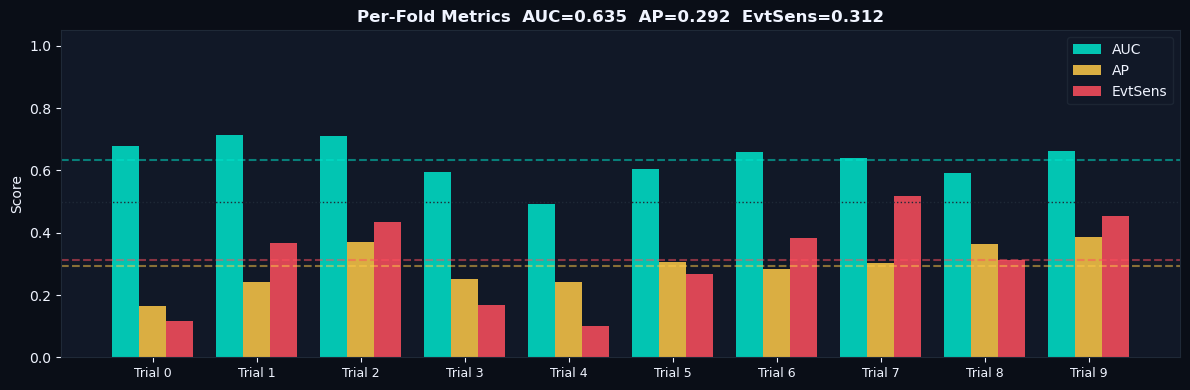

In [13]:
%matplotlib inline

trials = [r["trial"] for r in fold_results]
aucs = [r["auc"] for r in fold_results]
aps = [r["ap"] for r in fold_results]

# Per-trial event sensitivity (requires per-trial computation)
evt_sens_per_trial = []
for t in TEST_TRIALS:
    m = tid_all == t
    sc_t = scores_s[m]
    ym_t = y_mom[m]
    e = event_detection_metrics(
        sc_t,
        ym_t,
        threshold=thresh,
        horizon=HORIZON,
        fs_eff=FS_EFF,
        refractory=REFRACTORY,
    )
    evt_sens_per_trial.append(e["event_sensitivity"])

x = np.arange(len(trials))
w = 0.26
fig, ax = plt.subplots(figsize=(12, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE)

ax.bar(x - w, aucs, width=w, color=TEAL, alpha=0.85, label="AUC")
ax.bar(x, aps, width=w, color=GOLD, alpha=0.85, label="AP")
ax.bar(x + w, evt_sens_per_trial, width=w, color=CORAL, alpha=0.85, label="EvtSens")

ax.axhline(np.mean(aucs), color=TEAL, lw=1.5, ls="--", alpha=0.5)
ax.axhline(np.mean(aps), color=GOLD, lw=1.5, ls="--", alpha=0.5)
ax.axhline(np.mean(evt_sens_per_trial), color=CORAL, lw=1.5, ls="--", alpha=0.5)
ax.axhline(0.5, color=EDGE, lw=1, ls=":")

ax.set_xticks(x)
ax.set_xticklabels([f"Trial {t}" for t in trials], color=WHITE, fontsize=9)
ax.set_ylabel("Score", color=WHITE)
ax.set_title(
    f"Per-Fold Metrics  "
    f"AUC={np.mean(aucs):.3f}  AP={np.mean(aps):.3f}  "
    f"EvtSens={np.mean(evt_sens_per_trial):.3f}",
    color=WHITE,
    fontweight="bold",
)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("report/lgb_per_fold.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()

## 13 · ROC & Precision-Recall Curves

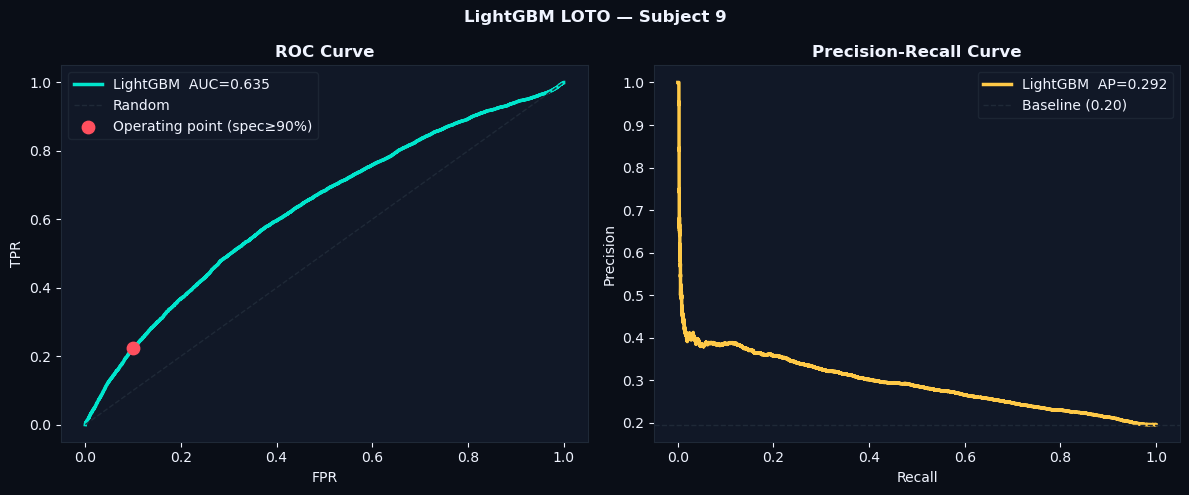

In [14]:
%matplotlib inline
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5), facecolor=DARK)

for ax in (ax_roc, ax_pr):
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    ax.tick_params(colors=WHITE)

# ROC
fpr, tpr, _ = roc_curve(y_all, scores_s)
ax_roc.plot(fpr, tpr, color=TEAL, lw=2.5, label=f'LightGBM  AUC={res["auc"]:.3f}')
ax_roc.plot([0, 1], [0, 1], color=EDGE, lw=1, ls="--", label="Random")

# Mark operating point at chosen threshold
op_fpr = 1 - MIN_SPEC
op_idx = np.argmin(np.abs(fpr - op_fpr))
ax_roc.scatter(
    fpr[op_idx],
    tpr[op_idx],
    color=CORAL,
    s=80,
    zorder=5,
    label=f"Operating point (spec≥{MIN_SPEC:.0%})",
)

ax_roc.set_xlabel("FPR", color=WHITE)
ax_roc.set_ylabel("TPR", color=WHITE)
ax_roc.set_title("ROC Curve", color=WHITE, fontweight="bold")
ax_roc.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

# PR
prec, rec, _ = precision_recall_curve(y_all, scores_s)
baseline_pr = y_all.mean()
ax_pr.plot(rec, prec, color=GOLD, lw=2.5, label=f'LightGBM  AP={res["ap"]:.3f}')
ax_pr.axhline(
    baseline_pr, color=EDGE, lw=1, ls="--", label=f"Baseline ({baseline_pr:.2f})"
)

ax_pr.set_xlabel("Recall", color=WHITE)
ax_pr.set_ylabel("Precision", color=WHITE)
ax_pr.set_title("Precision-Recall Curve", color=WHITE, fontweight="bold")
ax_pr.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

plt.suptitle(
    f"LightGBM LOTO — Subject {SUBJECT}", color=WHITE, fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("report/lgb_roc_pr.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()

## 14 · Feature Importance

Top features averaged and std-ranked across 10 LOTO folds.
Feature names encode channel and feature type: `ch{N}_{feature}`.

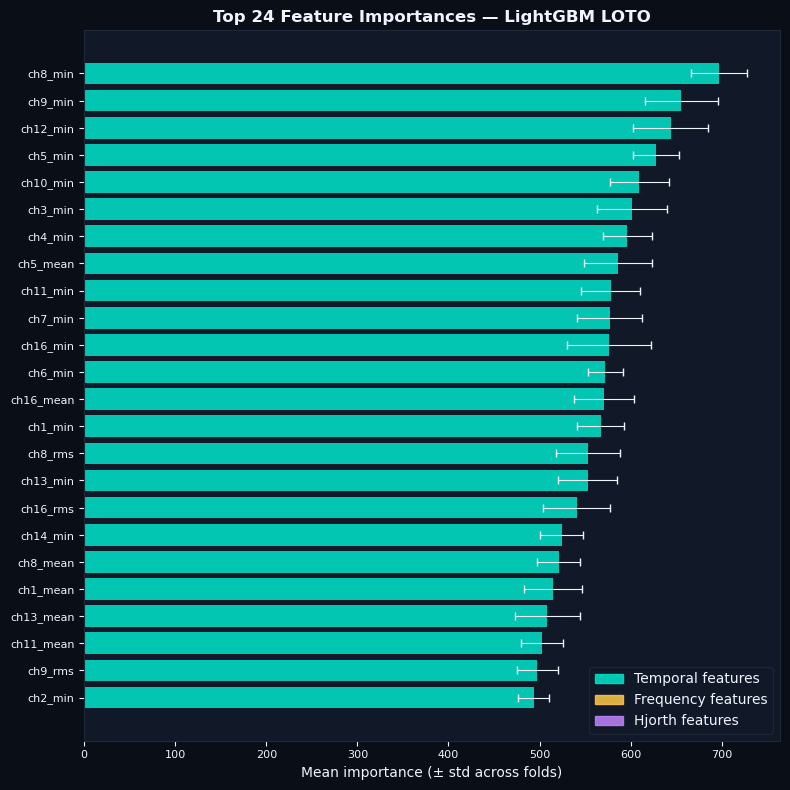

Saved → report/lgb_importance.png


In [15]:
%matplotlib inline
TOP_N = 24

order = np.argsort(mean_imp)[::-1][:TOP_N]
imp_top = mean_imp[order]
std_top = std_imp[order]
names = [FEAT_NAMES[i] for i in order]

family_colors = {
    "mean": TEAL,
    "std": TEAL,
    "slope": TEAL,
    "min": TEAL,
    "argmin": TEAL,
    "rms": TEAL,
    "delta": GOLD,
    "theta": GOLD,
    "entropy": GOLD,
    "activity": PURPLE,
    "mobility": PURPLE,
    "complexity": PURPLE,
}
bar_colors = [family_colors.get(n.split("_", 1)[1], WHITE) for n in names]

fig, ax = plt.subplots(figsize=(8, 8), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE, labelsize=8)

y_pos = np.arange(TOP_N)
ax.barh(
    y_pos,
    imp_top[::-1],
    xerr=std_top[::-1],
    color=bar_colors[::-1],
    alpha=0.85,
    error_kw=dict(ecolor=WHITE, capsize=3, lw=0.8),
)

ax.set_yticks(y_pos)
ax.set_yticklabels(names[::-1], fontsize=8, color=WHITE)
ax.set_xlabel("Mean importance (± std across folds)", color=WHITE)
ax.set_title(
    f"Top {TOP_N} Feature Importances — LightGBM LOTO", color=WHITE, fontweight="bold"
)

legend_handles = [
    mpatches.Patch(color=TEAL, alpha=0.85, label="Temporal features"),
    mpatches.Patch(color=GOLD, alpha=0.85, label="Frequency features"),
    mpatches.Patch(color=PURPLE, alpha=0.85, label="Hjorth features"),
]
ax.legend(handles=legend_handles, facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

plt.tight_layout()
plt.savefig("report/lgb_importance.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → report/lgb_importance.png")

## 15 · Detection Latency Distribution

For every detected press event, how many milliseconds *before* the press did the model first cross the threshold?  A distribution peaking near −500 ms confirms anticipatory detection, not reactive detection.

Detected events with latency data: 86
Median latency : -306 ms
Mean latency   : -294 ms


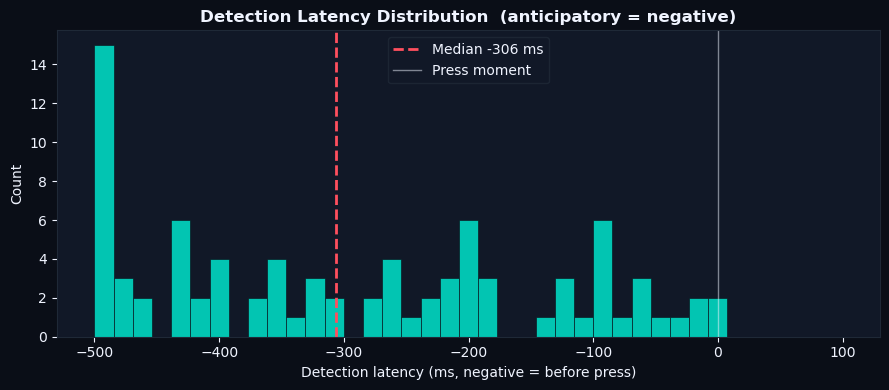

Saved → report/lgb_latency.png


In [16]:
%matplotlib inline

latencies_ms = []

for t in TEST_TRIALS:
    _, _, y_mom_t = raw_data[t]
    press_samps = np.where(y_mom_t > 0)[0]
    n_win_t = int((tid_all == t).sum())

    for ps in press_samps:
        win_k = ps - T_MAX
        if win_k < 1 or win_k >= n_win_t:
            continue
        gl_k = trial_offset[t] + win_k
        # Search backwards from press for first threshold crossing
        look_back = min(win_k, HORIZON)
        window = scores_s[gl_k - look_back : gl_k + 1]
        crossings = np.where(window >= thresh)[0]
        if len(crossings) == 0:
            continue  # missed event — skip
        # First crossing relative to press (negative = before)
        first_cross = crossings[0] - look_back  # ≤ 0
        latencies_ms.append(first_cross / FS_EFF * 1000)

latencies_ms = np.array(latencies_ms)
print(f"Detected events with latency data: {len(latencies_ms)}")
print(f"Median latency : {np.median(latencies_ms):.0f} ms")
print(f"Mean latency   : {np.mean(latencies_ms):.0f} ms")

fig, ax = plt.subplots(figsize=(9, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
ax.tick_params(colors=WHITE)

bins = np.linspace(-HORIZON / FS_EFF * 1000, 100, 40)
ax.hist(latencies_ms, bins=bins, color=TEAL, alpha=0.85, edgecolor=DARK, lw=0.5)
ax.axvline(
    np.median(latencies_ms),
    color=CORAL,
    lw=2,
    ls="--",
    label=f"Median {np.median(latencies_ms):.0f} ms",
)
ax.axvline(0, color=WHITE, lw=1, ls="-", alpha=0.5, label="Press moment")

ax.set_xlabel("Detection latency (ms, negative = before press)", color=WHITE)
ax.set_ylabel("Count", color=WHITE)
ax.set_title(
    "Detection Latency Distribution  (anticipatory = negative)",
    color=WHITE,
    fontweight="bold",
)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

plt.tight_layout()
plt.savefig("report/lgb_latency.png", dpi=120, bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved → report/lgb_latency.png")

## 16 · Summary

In [17]:
e = evt
print("=" * 55)
print(f"  LightGBM + Eng Features — Subject {SUBJECT}  LOTO CV")
print("=" * 55)
print(
    f"  Features       : {X_lgb.shape[1]}  (temporal {N_CH*6} + freq {N_CH*3} + Hjorth {N_CH*3})"
)
print(f"  Window (T_OPT) : {T_OPT/FS_EFF:.2f} s ({T_OPT} samples @ {FS_EFF} Hz)")
print(
    f"  Horizon        : {HORIZON/FS_EFF*1000:.0f} ms  Smooth: {SMOOTH_WIN/FS_EFF*1000:.0f} ms"
)
print(f"  Refractory     : {REFRACTORY/FS_EFF*1000:.0f} ms ({REFRACTORY} samples)")
print(f"  Threshold      : {thresh:.4f}  (spec ≥ {MIN_SPEC:.0%}, CV-tuned)")
print()
print(f'  LOTO AUC       : {res["auc"]:.4f}')
print(f'  LOTO AP        : {res["ap"]:.4f}')
print(f'  Event sens.    : {e["event_sensitivity"]:.3f}')
print(f'  FA / min       : {e["fa_per_minute"]:.1f}')
print(f'  Mean latency   : {e.get("mean_latency_ms", 0):.1f} ms')
print(f'  Events detected: {e["n_detected"]} / {e["n_events"]}')
print("=" * 55)
print()
print("Saved plots:")
for fname in [
    "lgb_timelines",
    "lgb_erp",
    "lgb_event_zoom",
    "lgb_per_fold",
    "lgb_roc_pr",
    "lgb_importance",
    "lgb_latency",
]:
    p = f"report/{fname}.png"
    exists = os.path.exists(p)
    print(f'  {p}  {"✓" if exists else "(not found)"}')

  LightGBM + Eng Features — Subject 9  LOTO CV
  Features       : 192  (temporal 96 + freq 48 + Hjorth 48)
  Window (T_OPT) : 0.19 s (12 samples @ 62 Hz)
  Horizon        : 500 ms  Smooth: 97 ms
  Refractory     : 500 ms (31 samples)
  Threshold      : 0.5485  (spec ≥ 90%, CV-tuned)

  LOTO AUC       : 0.6348
  LOTO AP        : 0.2916
  Event sens.    : 0.319
  FA / min       : 12.7
  Mean latency   : 300.5 ms
  Events detected: 84 / 263

Saved plots:
  report/lgb_timelines.png  ✓
  report/lgb_erp.png  ✓
  report/lgb_event_zoom.png  ✓
  report/lgb_per_fold.png  ✓
  report/lgb_roc_pr.png  ✓
  report/lgb_importance.png  ✓
  report/lgb_latency.png  ✓
